--- 模型配置信息 ---
API Key (前5位): sk-a8...
Base URL: https://dashscope.aliyuncs.com/compatible-mode/v1
TEMPERATURE (float): 0.5

配置成功，可以开始调用 API。


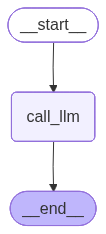

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='519f77d6-b52e-4e83-91c1-c3a4c4a41451')]}
================================ Human Message =================================

hi!
================================== Ai Message ==================================

Hi there! 😊 How can I help you today?


In [1]:
import os

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from env_utils import API_KEY, BASE_URL, MODEL_NAME
from IPython.display import display, Image


def call_llm(state: MessagesState):
    """示例节点函数：真实调用 ChatOpenAI 生成回复。

    参数:
        state: 当前图状态（这里是 MessagesState，包含 messages）。

    返回:
        一个状态增量（update），向消息列表追加一条 AI 回复消息。
    """
    model = ChatOpenAI(
        api_key=API_KEY,
        base_url=BASE_URL,
        model=MODEL_NAME,
    )
    print(state)
    ai_msg = model.invoke(state["messages"])
    return {"messages": [ai_msg]}


# 1) 创建图对象，并指定图状态 schema（MessagesState）。
graph = StateGraph(MessagesState)

# 2) 注册一个节点。未显式给名称时，节点名默认使用函数名 "call_llm"。
graph.add_node(call_llm)

# 3) 定义执行边：START -> call_llm。
graph.add_edge(START, "call_llm")

# 4) 定义执行边：call_llm -> END，表示该节点执行后流程结束。
graph.add_edge("call_llm", END)

# 5) 编译图。编译后才可以 invoke/stream。
graph = graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

# 6) 调用图执行。传入初始用户消息作为输入状态。
res = graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

# 7) 打印最终状态（会包含用户消息 + AI 消息）。
for r in res["messages"]:
    r.pretty_print()


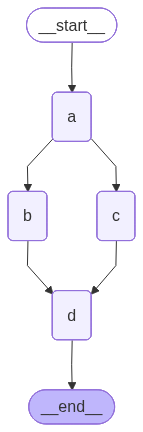

{'aggregate': ['A', 'B', 'C', 'D']}


In [3]:
import operator
from typing import Annotated

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

from IPython.display import display, Image

"""
Annotated 是 Python 的类型注解增强语法：给类型附加“额外元数据”。

例如：
Annotated[list, operator.add]
意思是：
基础类型是 list
额外附加了 operator.add 这个元数据
"""


class State(BaseModel):
    aggregate: Annotated[list, operator.add]


def a(state: State):
    return {"aggregate": ["A"]}


def b(state: State):
    return {"aggregate": ["B"]}


def c(state: State):
    return {"aggregate": ["C"]}


def d(state: State):
    return {"aggregate": ["D"]}


graph = StateGraph(State)

graph.add_node(b)
graph.add_node(c)
graph.add_node(d)
graph.add_node(a)

graph.add_edge(START, "a")
graph.add_edge("a", "b")
graph.add_edge("a", "c")
graph.add_edge("b", "d")
graph.add_edge("c", "d")
graph.add_edge("d", END)
graph = graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

res = graph.invoke({"aggregate": []})
print(res)
# graph.invoke({"aggregate": ["A", "B"]})
